# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [3]:
# import data set
df = pd.read_csv( 'cancer.csv' )
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [9]:
# drop ID column as it is useless for the model
if 'ID' in df.columns:
    df.drop(['ID'], axis=1, inplace = True)

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [10]:
# print datatype pf each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [5]:
# Shape of database
df.shape

(699, 11)

In [7]:
# study the Data Distribution for each attribute
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,699.0,1.071704e+06,617095.729819,61634.0,870688.5,1171710.0,1238298.0,13454352.0
ClumpThickness,699.0,4.417740e+00,2.815741,1.0,2.0,4.0,6.0,10.0
Cell Size,699.0,3.134478e+00,3.051459,1.0,1.0,1.0,5.0,10.0
Cell Shape,699.0,3.207439e+00,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,699.0,2.806867e+00,2.855379,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,699.0,3.216023e+00,2.214300,1.0,2.0,2.0,4.0,10.0
Normal Nucleoli,699.0,3.437768e+00,2.438364,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,699.0,2.866953e+00,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413e+00,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,2.689557e+00,0.951273,2.0,2.0,2.0,4.0,4.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001AB1605BBA8>,
      dtype=object)

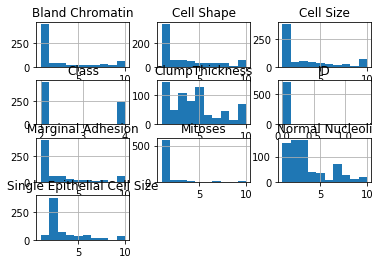

In [8]:
# Plot the distribution of variables using histogram
df.hist()


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [0]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [12]:
# check how many missing values
df.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [0]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [26]:
# check for non-numeric values
temp = pd.DataFrame(df['Bare Nuclei'].str.isdigit())  
temp[temp['Bare Nuclei'] == False].count() 

Bare Nuclei    16
dtype: int64

In [0]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [27]:
# check for non-numeric values
df = df.replace('?', np.nan)
df = df.apply(lambda x: x.fillna(x.median()),axis=0)

In [30]:
# converting the column from object 'Bare Nuclei' string type to float
df['Bare Nuclei'] = df['Bare Nuclei'].astype('float64')  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null float64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [0]:
# Check for correlation of variable

In [31]:
df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034,0.716001
Cell Size,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693,0.817904
Cell Shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397,0.818968
Normal Nucleoli,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336,0.712244
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000,0.423170
Class,0.716001,0.817904,0.818934,0.696800,0.682785,0.818968,0.756616,0.712244,0.423170,1.000000


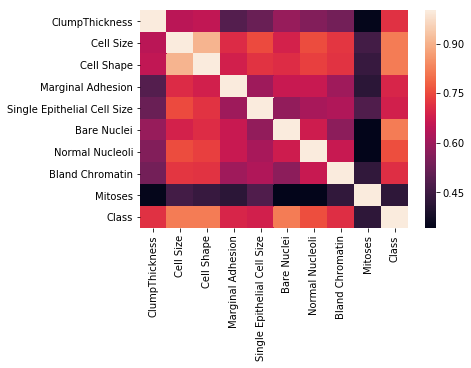

In [47]:
sns.heatmap(df.corr())

In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [0]:
#Let us check for pair plots

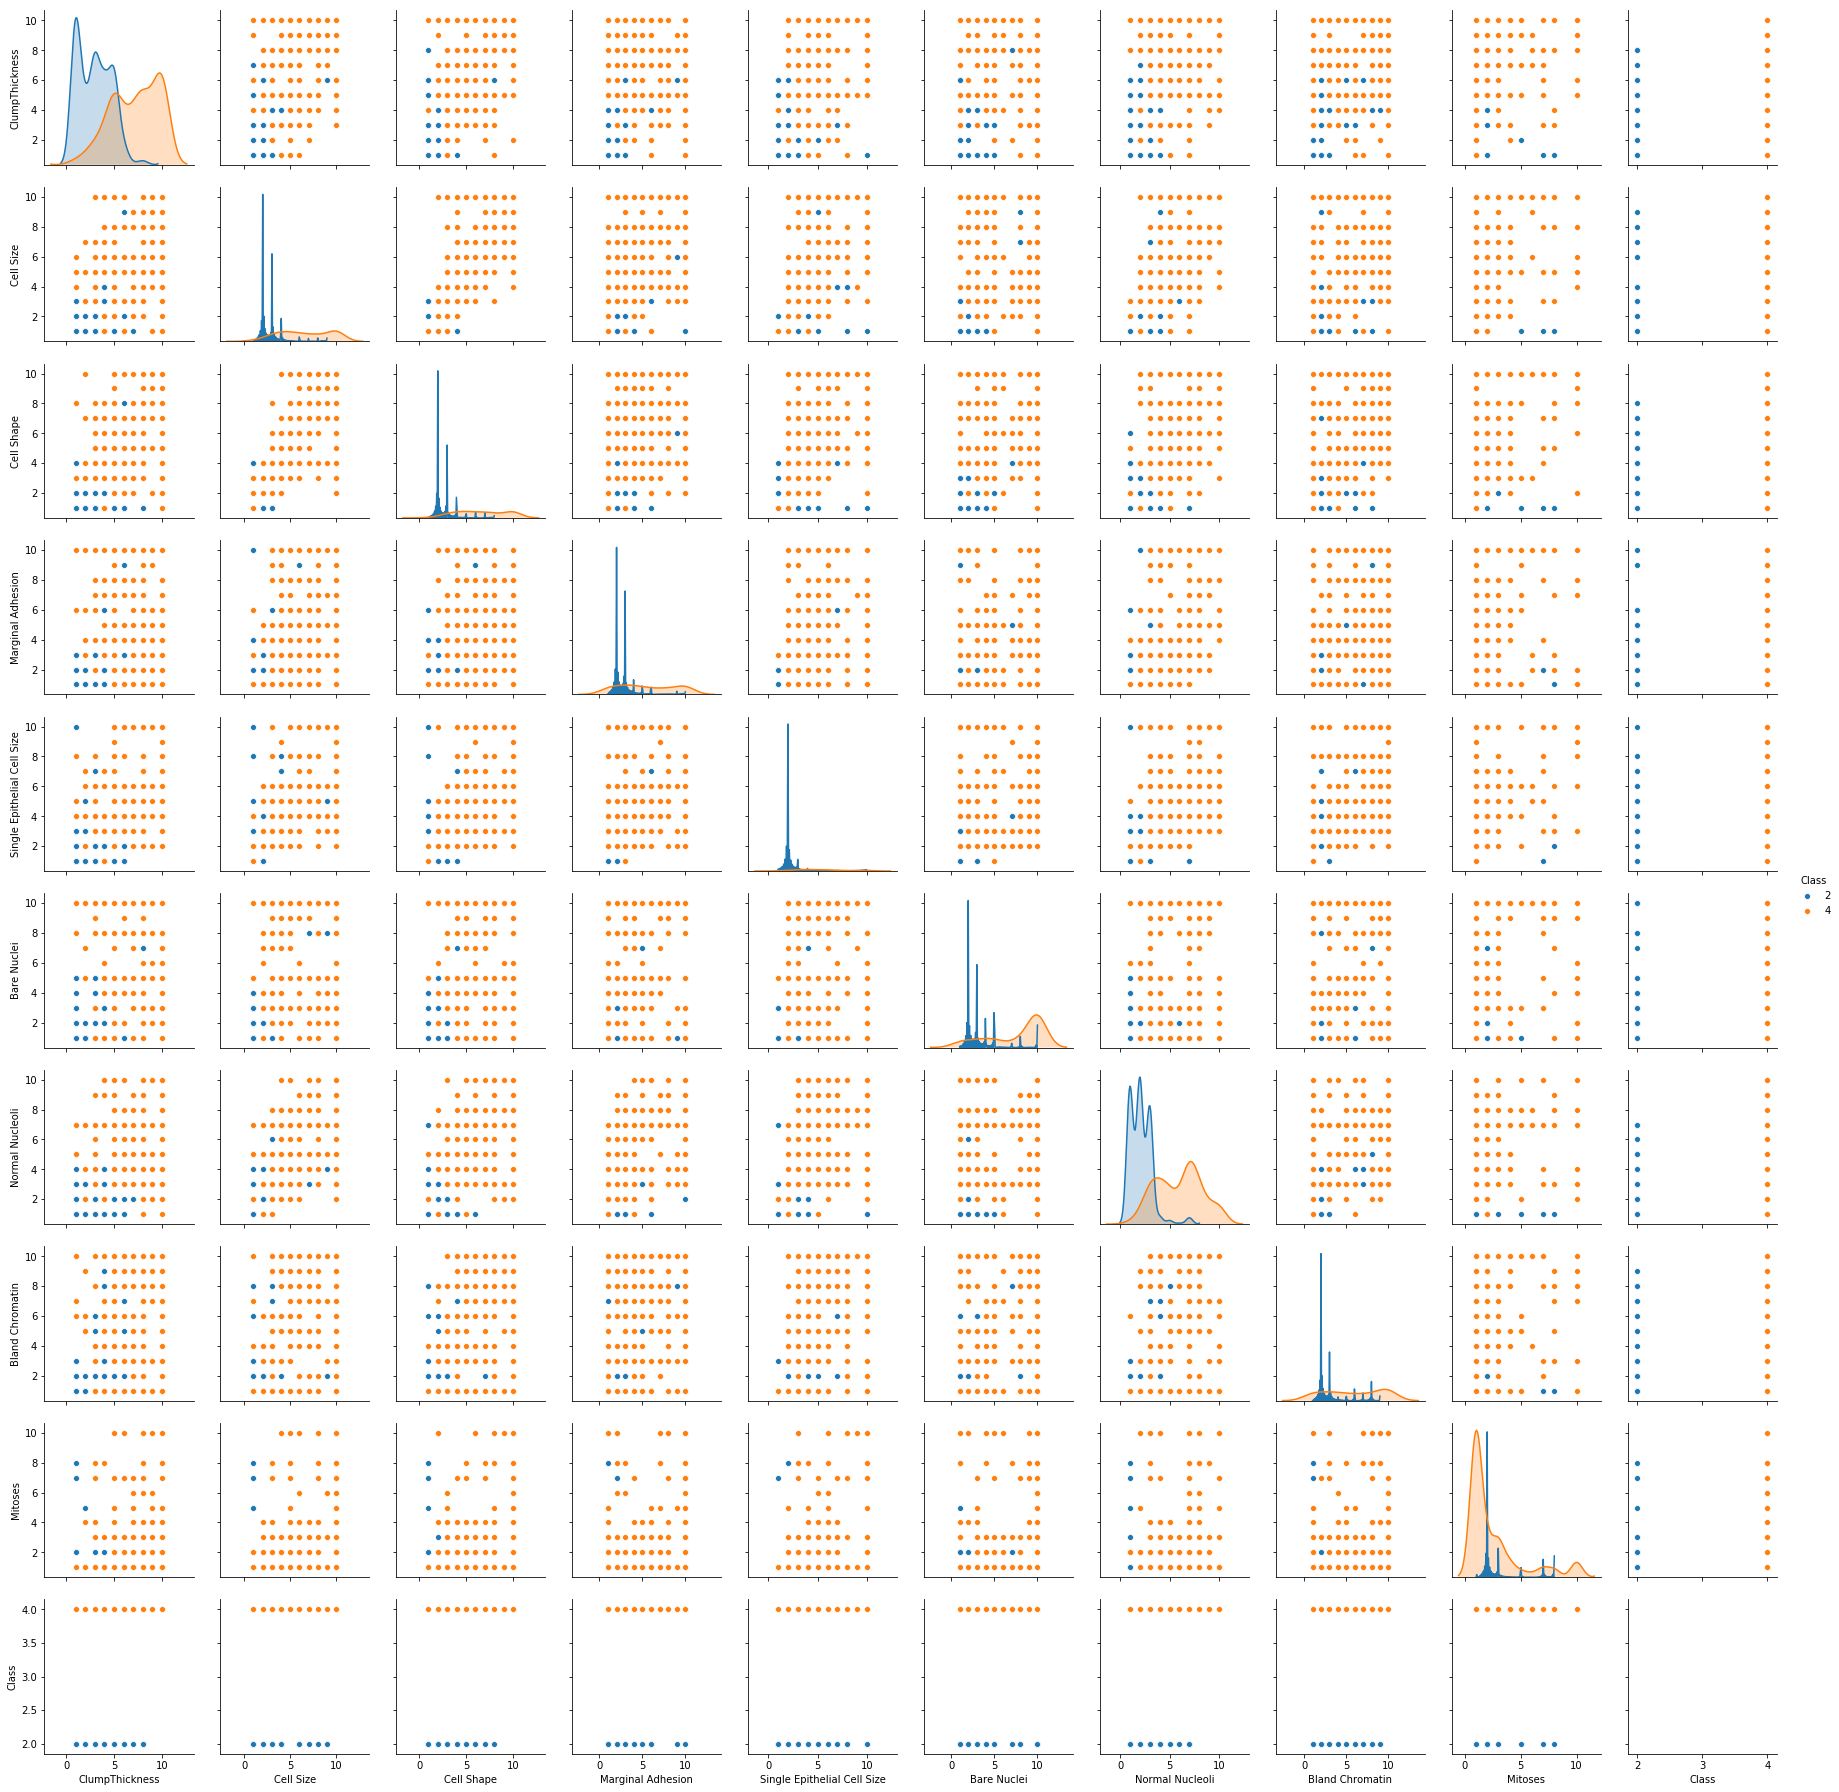

In [38]:
# Pairplot using sns
sns.pairplot(df,hue="Class",diag_kind="kde")

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

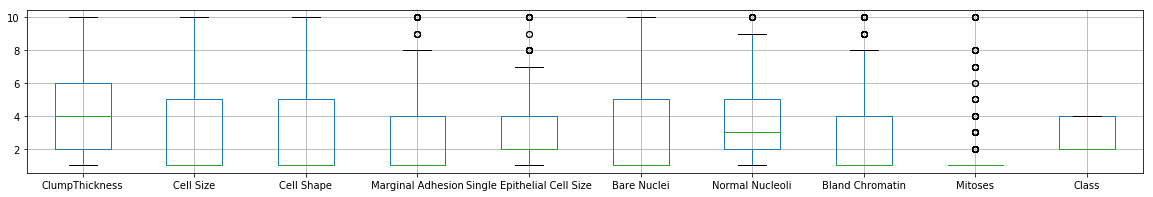

In [103]:
# check for outliers
df.boxplot(figsize=(20, 3))

In [ ]:
# We could see outliers in few of the columns
# check if we need to remove any value

In [104]:
df['Class'].value_counts()

2    458
4    241
Name: Class, dtype: int64

In [109]:
pd.crosstab(df['Marginal Adhesion'],df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,5,28
5,4,19
6,4,18
7,0,13
8,0,25
9,1,4


In [108]:
pd.crosstab(df['Single Epithelial Cell Size'],df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,7,41
5,5,34
6,2,39
7,3,9
8,2,19
9,0,2


In [110]:
pd.crosstab(df['Bland Chromatin'],df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,1,17
5,2,17
6,4,18
7,2,14
8,4,20
9,1,15


In [106]:
pd.crosstab(df['Mitoses'],df['Class'])

Class,2,4
Mitoses,,
1,445,134
2,8,27
3,2,31
4,0,12
5,1,5
6,0,3
7,1,8
8,1,7
10,0,14


In [101]:
# Prepare X and Y
X = df.drop("Class", axis=1)
y = df["Class"]

In [100]:
# standardize variables

from scipy.stats import zscore
# apply z_score
X_std = X.apply(zscore) 

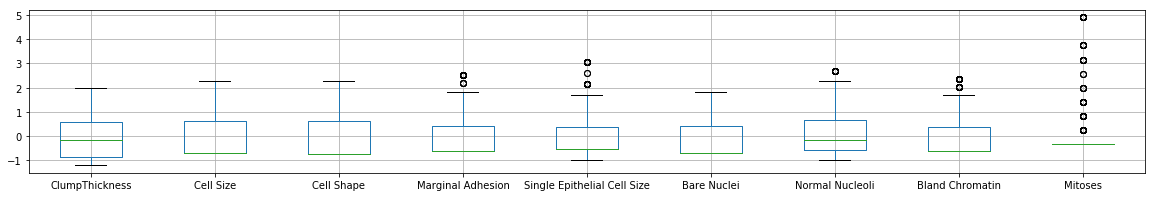

In [112]:
X_std.boxplot(figsize=(20, 3))

# Q6 Create a covariance matrix for identifying Principal components

In [113]:
# PCA
# Step 1 - Create covariance matrix


In [114]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.5908535
  0.5592282  0.53660222 0.35053534]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68765657
  0.75680368 0.72390044 0.4593503 ]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.70848734
  0.73700282 0.72047704 0.43953974]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66792658
  0.66767051 0.60421681 0.41823111]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.5845377
  0.61698451 0.62978166 0.47978787]
 [0.5908535  0.68765657 0.70848734 0.66792658 0.5845377  1.00143266
  0.67518063 0.5756016  0.34288766]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.67518063
  1.00143266 0.66683179 0.34466258]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.5756016
  0.66683179 1.00143266 0.42894941]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.34288766
  0.34466258 0.42894941 1.00143266]]


# Q7 Identify eigen values and eigen vector

In [115]:
# Step 2- Get eigen values and eigen vector

In [116]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

In [117]:
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.30280515  0.14602888 -0.86221719 -0.0014072  -0.08821658 -0.07192848
  -0.24081701  0.26946934 -0.00131277]
 [-0.38119012  0.04956364  0.01909154 -0.73568065  0.2026394   0.13735749
   0.44088652  0.1000979   0.21521315]
 [-0.37757351  0.08526953 -0.0345843   0.66537497  0.17515522  0.10469081
   0.58600968  0.03200191  0.14204379]
 [-0.33282286  0.04471887  0.42144828  0.04671812 -0.4703171  -0.03462797
  -0.11866965  0.68083355 -0.0861038 ]
 [-0.33639134 -0.16403795  0.11010437  0.06786939  0.37332927  0.68258246
  -0.45057208 -0.03559797 -0.18337725]
 [-0.33349748  0.2477099  -0.00367104 -0.07339423 -0.5431767   0.1275059
   0.10299896 -0.57486596 -0.41187463]
 [-0.3459564   0.22994199  0.19744944  0.05881119 -0.00698988 -0.25519148
  -0.40975993 -0.31459721  0.67301535]
 [-0.33584019 -0.02502678  0.13164974 -0.01889835  0.45537199 -0.63180293
  -0.08247514 -0.03841564 -0.50406321]
 [-0.22981766 -0.90839421 -0.09459348  0.0075291  -0.23968608 -0.1316273
   0.0

# Q8 Find variance and cumulative variance by each eigen vector

In [118]:
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]

In [119]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 65.4457038   74.05429355  80.04128903  85.21615907  89.44363313
  92.81719904  96.10243391  99.01309194 100.        ]


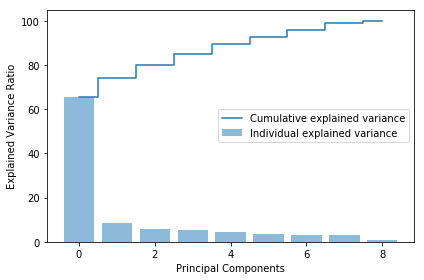

In [120]:
plt.figure(figsize=(6 , 4))
plt.bar(range(9), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(9), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [121]:
# First three principal components explain more than 80% of the variance in the data. 

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [122]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=4, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [123]:
# transform based on the principal components
X_pca = pca.transform(X_std)
X_pca.shape

(699, 4)

In [124]:
pca.components_
pca.explained_variance_

array([5.8985519 , 0.77588307, 0.53960155, 0.46640555])

In [125]:
pca.explained_variance_ratio_

array([0.65445704, 0.0860859 , 0.05986995, 0.0517487 ])

# Q10 Find correlation between components and features

In [126]:
type(X_pca)

numpy.ndarray

In [127]:
pca_df = pd.DataFrame(X_pca)  # converting array to dataframe for pairplot

In [128]:
pca_df.corr()

,0,1,2,3
0,1.000000e+00,3.354100e-15,-3.252373e-16,-1.292677e-16
1,3.354100e-15,1.000000e+00,3.377589e-16,6.411897e-17
2,-3.252373e-16,3.377589e-16,1.000000e+00,3.952106e-16
3,-1.292677e-16,6.411897e-17,3.952106e-16,1.000000e+00


C:\Users\Suchi\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


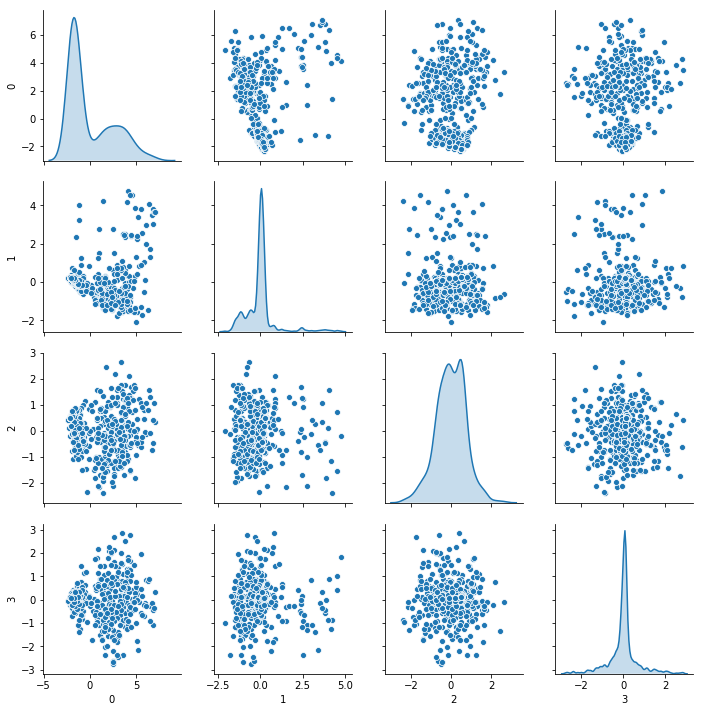

In [129]:
sns.pairplot(pca_df,diag_kind="kde")